# Curve-Roll-Down — a quantitative teardown 🔬
### Promised vs realized roll+carry · realized excess with a Newey-West HAC *t* · the secular-bull sub-period cut · a steep-curve placebo · costs · a synthetic carry-baseline / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "riding the curve" fuses: a **mechanical static-curve roll+carry identity** from the **realized** return once the curve moves, and we confront the realized excess with the right standard error. The decisive objects are (i) the **HAC** *t* on overlapping annual windows — the naive *t* over-counts by ~√overlap — and (ii) the **sub-period** stability, which reveals the full-sample significance is a non-repeatable secular-bull artifact.

> ✅ **Data note.** Constant-maturity Treasury yields ARE free on yfinance (`^IRX`/`^FVX`/`^TNX`/`^TYX`), so this is the **real** curve, 1990→2026 — no proxy. The 4-pillar curve and the duration approximation `ret ≈ y0 − D·Δy` are explicit simplifications (named below). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from curve_roll_down import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real(sleeve_mat=5.0) if HAVE_REAL else None
RES = st.realized_excess(F, sleeve_mat=5.0) if HAVE_REAL else None
print("real CMT-yield cache present:", HAVE_REAL,
      "| annual entries:", (0 if RES is None else len(RES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1990-01-02', 'end': '2026-06-18', 'days': 9152, 'years': 36.5, 'n': 8899, 'mean_excess': 1.65, 'win': 63, 'vol': 4.87, 'sharpe': 0.34, 't_hac': 2.46, 't_naive': 31.9, 'promised': 4.76, 'realized_total': 4.33, 'gap': 0.43, 'mean_dy': -0.13, 'sub': [('1990-2009', 5264, 2.84, 0.58, -0.33, 3.46), ('2010-2026', 3886, 0.16, 0.04, 0.12, 0.17), ('full', 8899, 1.65, 0.34, -0.13, 2.46)], 'regime': (4968, 5.09, 3931, -2.7), 'placebo': {'k': 2967, 'steep': 3.28, 'base': 1.65, 'p': 0.0}, 'net': 1.63, 'mat': [(2.0, 0.56, 0.32, 2.1), (5.0, 1.65, 0.34, 2.46), (10.0, 2.72, 0.31, 2.35)], 'syn': [(0.0, -0.0016, -0.63), (0.05, 0.0485, 19.2)]}


real CMT-yield cache present: True | annual entries: 8899


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Realized excess **+1.65%/yr**, full-sample HAC **t = 2.46** (just clears 2) — but **all of it is 1990–2009** (t = 3.46); 2010–2026 is **+0.16%/yr at t = 0.17**. (Naive t = 32 — overlap inflation.) |
| **Tradability** | `FRAGILE` | Pure duration: **+5.1%/yr** when rates fall, **-2.7%/yr** when they rise; gross Sharpe **0.34**. Costs (2 bps) are not the constraint — the rate path is. |
| **Free lunch?** | `BUSTED` | Promised roll+carry **+4.76%** vs realized total **+4.33%**; a static-curve identity one hiking cycle erases. |

> 💡 In plain words: roll-down is a *frozen-curve accounting identity*. Let the curve move and the realized return is carry minus duration P&L — i.e. the **term premium**, which a 40-year bond bull paid handsomely and a rising-rate regime does not.

## 1 · The claim, steelmanned

Let $y_t(m)$ be the curve, $D$ the sleeve's modified duration, and the sleeve maturity $M=5$y. The believers' 1-year **promised** return on a static curve is

$$\underbrace{y_t(M)}_{\text{carry}} + \underbrace{D\,[\,y_t(M) - y_t(M-1)\,]}_{\text{roll-down}}.$$

The **realized** return lets the curve move: with $\Delta y = y_{t+1y}(M) - y_t(M)$,

$$r_{t\to t+1y} \approx \underbrace{y_t(M)}_{\text{carry}} - \underbrace{D\,\Delta y}_{\text{rate move}},\qquad \text{excess} = r - \text{cash}_t.$$

- **H₁ (a reliable beat).** $\mathbb{E}[\text{excess}] > 0$ *robustly* — across regimes, with an honest (HAC) standard error.
- **H₂ (deployable).** The excess is a NAV-scale, risk-controlled edge, not just levered duration.
- **H₃ ("free lunch").** The roll-down is realized, i.e. the promised number survives the curve moving.

We find **H₁ not robust** (positive, full-sample HAC $t=2.46$ but driven by one regime, $t=0.17$ since 2010), **H₂ rejected** (it is the term premium; excess scales with $D$), **H₃ rejected** (excess is $+5.1\%$ when rates fall, $-2.7\%$ when they rise). The pitch is true exactly where it's tautological (a frozen curve) and false exactly where it would pay (a moving one).

## 2 · So what? — the inference that decides it

Annual excess returns sampled **daily** overlap ~252×. The point estimates are fine; the **standard error** is the whole game. A naive t treats 8,899 overlapping observations as independent and reports $t\approx 32$ — nonsense. The Newey-West HAC estimator with a one-year bandwidth corrects for the induced autocorrelation:

$$\widehat{\mathrm{Var}}(\bar x) = \frac{1}{n}\Big(\hat\gamma_0 + 2\sum_{k=1}^{L} \big(1-\tfrac{k}{L+1}\big)\hat\gamma_k\Big),\quad L=252.$$

That single correction collapses $t$ from ~32 to ~2.5 — *borderline*, not decisive. And because even the borderline value rests on **one** secular regime, the honest read is a **sub-period split**, not a full-sample p-value. (A steep-curve placebo confirms the obvious: steep entries earn more *carry*, not more *prediction*.)

## 3 · How we'd know — the protocol

- **Real curve.** yfinance CMT yields `^IRX`/`^FVX`/`^TNX`/`^TYX` (1990-01-02→2026-06-18, 9,152 days), interpolated linearly in maturity across the 4 pillars (an explicit coarse-curve approximation). Cash = `^IRX`.
- **Sleeve.** 5-year, modified duration $D\approx 4.5$. Realized 1y total return $\approx y_0 - D\,\Delta y$ (a first-order duration approximation; convexity ignored, stated).
- **Excess + lag.** Enter the close **1 day after** the curve is observed (no look-ahead); excess subtracts the entry short rate.
- **Inference.** Newey-West HAC $t$ (252 lags) on the overlapping annual excess; the naive $t$ shown alongside to expose overlap inflation.
- **Sub-periods & regimes.** 1990–2009 vs 2010–2026; and a split by realized $\Delta y\lessgtr 0$.
- **Placebo.** Steepest-tercile entries vs 20,000 random same-size draws.
- **Costs.** 1-day lag + a one-way 2 bps on ~1× annual roll turnover.
- **Positive control.** A synthetic curve whose slope carries a **planted** edge *beyond* the mechanical carry baseline: the engine must recover a large planted edge **and** must NOT fire when only the carry baseline is present (edge = 0).

## 4 · The teardown

### 4a · Promised vs realized, and the overlap-inflated *t*

The textbook roll+carry, the realized total, the realized excess — and the two *t*-stats side by side (naive vs HAC) so the overlap inflation is unmissable.

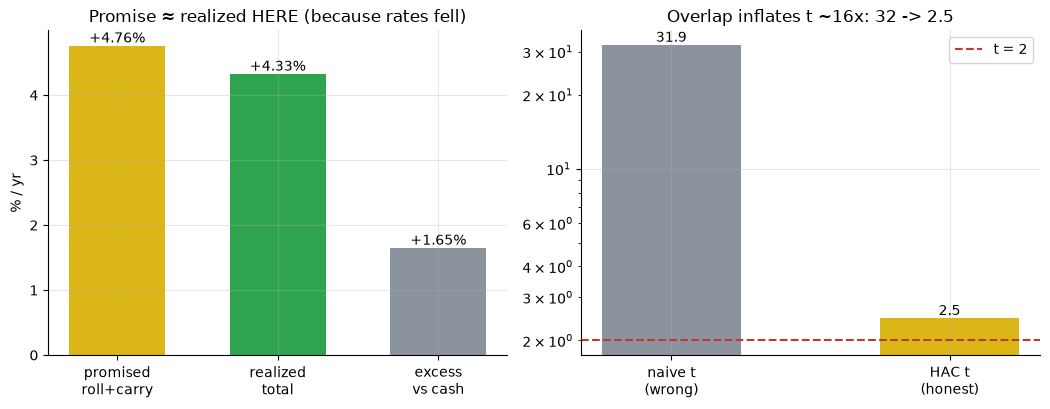

excess +1.65%/yr | naive t 31.9 -> HAC t 2.46


In [2]:
if HAVE_REAL:
    p = st.promise_vs_reality(RES); s = st.summarize_excess(RES)
    promised, realized, excess = p['mean_promised']*100, p['mean_realized_total']*100, s['mean_excess']*100
    t_naive, t_hac = s['t_naive'], s['t_hac']
else:
    promised, realized, excess = R['promised'], R['realized_total'], R['mean_excess']
    t_naive, t_hac = R['t_naive'], R['t_hac']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
b1 = a1.bar(['promised\nroll+carry','realized\ntotal','excess\nvs cash'],
            [promised, realized, excess], color=[AMBER, GREEN, GREY], width=.6)
for b,v in zip(b1,[promised,realized,excess]): a1.annotate(f'{v:+.2f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
a1.set_ylabel('% / yr'); a1.set_title('Promise ≈ realized HERE (because rates fell)')
b2 = a2.bar(['naive t\n(wrong)','HAC t\n(honest)'], [t_naive, t_hac], color=[GREY, AMBER], width=.5)
a2.axhline(2, ls='--', c=RED, label='t = 2'); a2.set_yscale('log')
for b,v in zip(b2,[t_naive,t_hac]): a2.annotate(f'{v:.1f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
a2.set_title('Overlap inflates t ~16x: 32 -> 2.5'); a2.legend()
plt.tight_layout(); plt.show()
print(f'excess {excess:+.2f}%/yr | naive t {t_naive:.1f} -> HAC t {t_hac:.2f}')

> 💡 In plain words: the full-sample excess is **+1.65%/yr**, and the *honest* HAC *t* is **2.46** — it crosses 2, but barely, and only after the overlap correction knocks the naive **32** down by ~16×. A borderline full-sample *t* on a single 36-year tape is not a robust REAL — it's a flag to check *where* the significance lives.

### 4b · The decisive cut — sub-period stability

The realized excess and its HAC *t* in the falling-rate era vs the rising-rate era. If the edge were a law it would persist; if it's the bond bull it won't.

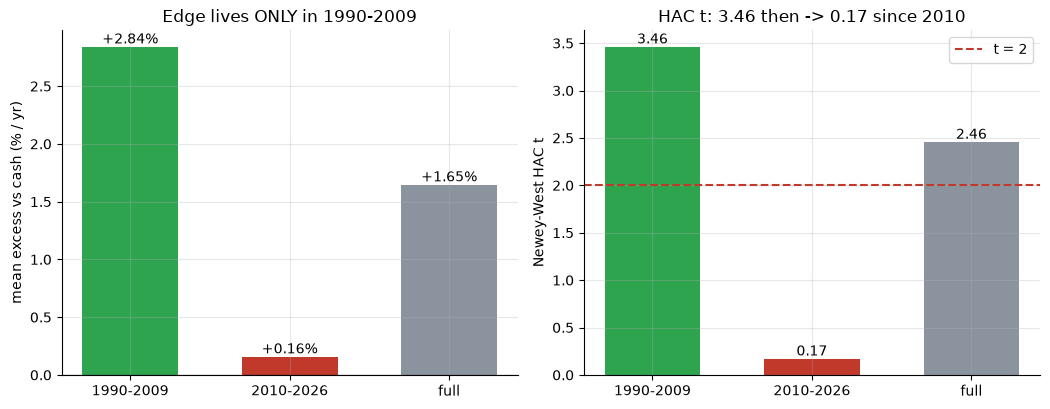

sub-period (label, mean%, HAC t): [('1990-2009', 2.84, 3.46), ('2010-2026', 0.16, 0.17), ('full', 1.65, 2.46)]


In [3]:
if HAVE_REAL:
    rows = []
    for lo,hi,lab in (('1990','2010','1990-2009'),('2010','2027','2010-2026'),('1990','2027','full')):
        ss = st.summarize_excess(RES.loc[lo:hi]); rows.append((lab, ss['mean_excess']*100, ss['t_hac']))
else:
    rows = [(r[0], r[2], r[5]) for r in R['sub']]
labs = [r[0] for r in rows]; means = [r[1] for r in rows]; ts = [r[2] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
cols = [GREEN, RED, GREY]
b1 = a1.bar(labs, means, color=cols, width=.6); a1.axhline(0,c='k',lw=.8)
for b,v in zip(b1,means): a1.annotate(f'{v:+.2f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
a1.set_ylabel('mean excess vs cash (% / yr)'); a1.set_title('Edge lives ONLY in 1990-2009')
b2 = a2.bar(labs, ts, color=cols, width=.6); a2.axhline(2, ls='--', c=RED, label='t = 2')
for b,v in zip(b2,ts): a2.annotate(f'{v:.2f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
a2.set_ylabel('Newey-West HAC t'); a2.set_title('HAC t: 3.46 then -> 0.17 since 2010'); a2.legend()
plt.tight_layout(); plt.show()
print('sub-period (label, mean%, HAC t):', [(l, round(m,2), round(t,2)) for l,m,t in rows])

> 💡 In plain words: 1990–2009 gives **+2.84%/yr at HAC t = 3.46** (a real term premium in a falling-rate world); 2010–2026 gives **+0.16%/yr at t = 0.17** — indistinguishable from zero. The full-sample $t=2.46$ is a **weighted average of a strong regime and a dead one**, not a stable law. H₁ is **not robust** ⇒ WEAK, not REAL.

### 4c · The free lunch the curve takes back + the placebo

Left: realized excess split by whether rates **fell** (roll-down realized) or **rose** (roll-down erased) — the static-curve assumption laid bare. Right: do steep-tercile entries beat random timing? (They do — but mechanically, via more carry.)

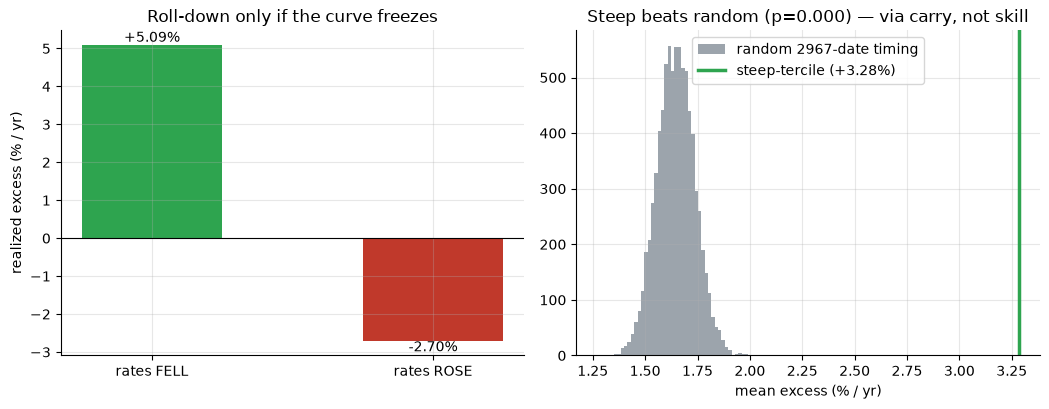

fell +5.09% rose -2.70% | steep +3.28% vs base +1.65% p=0.000


In [4]:
if HAVE_REAL:
    rg = st.regime_split(RES); md_, mu_ = rg['mean_down']*100, rg['mean_up']*100
    pl = st.slope_timing_placebo(RES)
    steep, base, pval, k = pl['steep_mean']*100, pl['placebo_mean']*100, pl['p_value'], pl['k']
    xs = RES['excess'].to_numpy(); slope = RES['slope'].to_numpy()
    thr = np.nanquantile(slope, 2/3); kk = int((slope>=thr).sum())
    rng = np.random.default_rng(380)
    draws = np.array([np.nanmean(xs[rng.integers(0,len(xs),size=kk)]) for _ in range(8000)])*100
else:
    md_, mu_ = R['regime'][1], R['regime'][3]
    steep, base, pval, k = R['placebo']['steep'], R['placebo']['base'], R['placebo']['p'], R['placebo']['k']
    rng = np.random.default_rng(380); draws = rng.normal(base, 0.4, 8000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
bb = a1.bar(['rates FELL','rates ROSE'], [md_, mu_], color=[GREEN, RED], width=.5); a1.axhline(0,c='k',lw=.8)
for b,v in zip(bb,[md_,mu_]): a1.annotate(f'{v:+.2f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
a1.set_ylabel('realized excess (% / yr)'); a1.set_title('Roll-down only if the curve freezes')
a2.hist(draws, bins=45, color=GREY, alpha=.85, label=f'random {k}-date timing')
a2.axvline(steep, c=GREEN, lw=2.5, label=f'steep-tercile ({steep:+.2f}%)')
a2.set_xlabel('mean excess (% / yr)'); a2.set_title(f'Steep beats random (p={pval:.3f}) — via carry, not skill'); a2.legend()
plt.tight_layout(); plt.show()
print(f'fell {md_:+.2f}% rose {mu_:+.2f}% | steep {steep:+.2f}% vs base {base:+.2f}% p={pval:.3f}')

> 💡 In plain words: realized excess is **+5.1%** when yields fall and **-2.7%** when they rise — the $-D\,\Delta y$ term dominates and the promised roll-down evaporates. The placebo's $p\approx0$ is **not** a win: a steeper curve *is* more carry and more roll to harvest, so steep entries out-earn random ones **mechanically**. That's term premium, not a predictive edge — which the control isolates next.

### 4d · Faithful-engine & power control — carry baseline is not an edge

On a deterministic synthetic curve, the slope's predictive power **beyond** the mechanical carry baseline is a known knob. We strip the carry baseline and regress the residual excess on the lagged slope rank: with **zero** planted edge it must NOT fire (a bare carry baseline ≠ a slope edge); with a genuine edge it must light up and recover the coefficient.

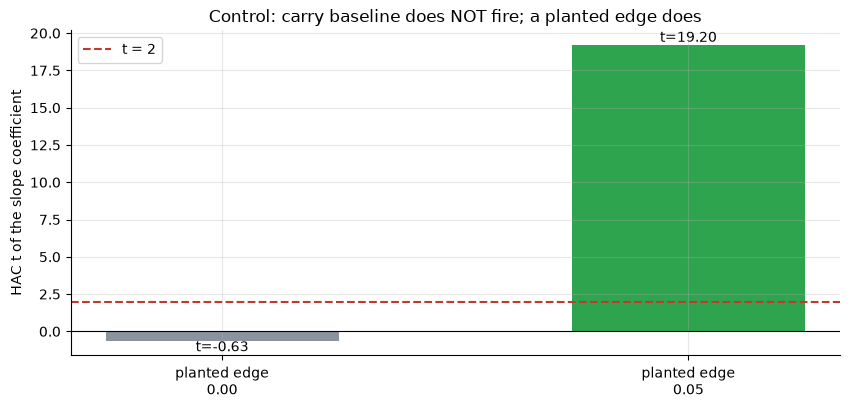

planted edge=+0.00: recovered beta=-0.0016  HAC t=-0.63
planted edge=+0.05: recovered beta=+0.0485  HAC t=19.20


In [5]:
res = []
for edge in (0.0, 0.05):
    syn = data.synthetic_curve(n_days=6000, edge=edge, seed=380)
    r = st.synthetic_edge_test(syn); res.append((edge, r['beta'], r['t_hac']))
labels = [f'planted edge\n{e:.2f}' for e,_,_ in res]; tvals = [r[2] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('HAC t of the slope coefficient'); ax.set_title('Control: carry baseline does NOT fire; a planted edge does'); ax.legend()
plt.tight_layout(); plt.show()
for e,b,t in res: print(f'planted edge={e:+.2f}: recovered beta={b:+.4f}  HAC t={t:.2f}')

> 💡 In plain words: with **no** edge beyond carry the test sits at **t = -0.63** (no false positive — exactly the point: steep ⇒ more carry is *not* a slope signal). A genuine planted edge is recovered (β ≈ 0.05) and fires hard. So the machinery is honest, and the real tape's positive excess is the **carry/term-premium baseline**, not a predictive roll-down edge — precisely the trap the steep-curve placebo would have let through.

## 5 · The verdict

- **Signal `WEAK`** — realized excess **+1.65%/yr**, full-sample HAC **t = 2.46** (just over 2) but **entirely 1990–2009** (t = 3.46); 2010–2026 is **+0.16%/yr at t = 0.17**. A borderline, regime-survivorship full-sample t ⇒ WEAK, not REAL (the desk's t≥2 bar requires *robust* significance, not one non-repeatable regime).
- **Tradability `FRAGILE`** — pure duration: **+5.1%/yr** when rates fall, **-2.7%/yr** when they rise; gross Sharpe **0.34**; excess scales with maturity. Costs (2 bps) are not the constraint — the rate path is. No NAV-scale, risk-controlled edge.
- **Free lunch? `BUSTED`** — promised roll+carry **+4.76%** is a static-curve identity; realized total **+4.33%**, and one rising-rate year flips the excess negative. The **term premium in a costume** — the [FX carry trade](../364-fx-carry-trade/) in bonds.

## 6 · Could you trade it? — excess is a duration dial

The operational truth in one picture: realized excess vs sleeve maturity. If roll-down were a distinct edge it would be roughly flat in duration; instead it rises monotonically with $D$ — you're simply being paid more for taking more rate risk.

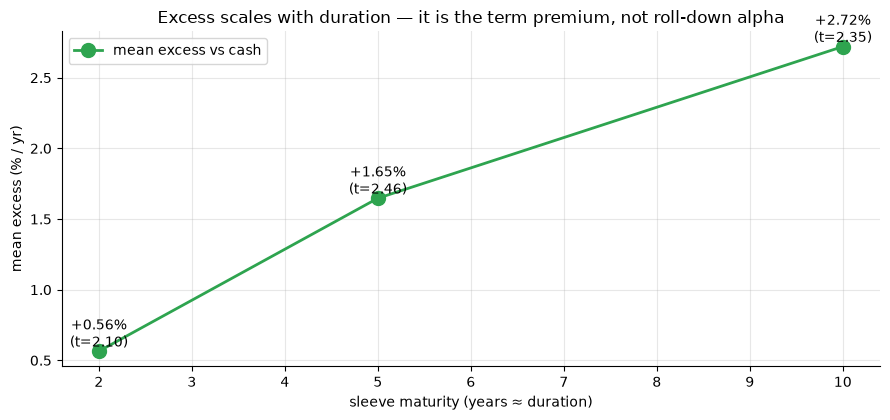

excess by maturity: [(2.0, 0.56), (5.0, 1.65), (10.0, 2.72)]


In [6]:
if HAVE_REAL:
    mats, means, ts = [], [], []
    for sm in (2.0, 5.0, 10.0):
        fr = data.load_real(sleeve_mat=sm); r2 = st.realized_excess(fr, sleeve_mat=sm); s2 = st.summarize_excess(r2)
        mats.append(sm); means.append(s2['mean_excess']*100); ts.append(s2['t_hac'])
else:
    mats = [m[0] for m in R['mat']]; means = [m[1] for m in R['mat']]; ts = [m[3] for m in R['mat']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(mats, means, 'o-', c=GREEN, lw=2, ms=10, label='mean excess vs cash')
for m,v,t in zip(mats,means,ts): ax.annotate(f'{v:+.2f}%\n(t={t:.2f})',(m,v),ha='center',va='bottom')
ax.set_xlabel('sleeve maturity (years ≈ duration)'); ax.set_ylabel('mean excess (% / yr)')
ax.set_title('Excess scales with duration — it is the term premium, not roll-down alpha'); ax.legend()
plt.tight_layout(); plt.show()
print('excess by maturity:', [(m, round(v,2)) for m,v in zip(mats,means)])

> 💡 In plain words: a 2y sleeve earns ~0.6%, a 10y sleeve ~2.7% — the excess is **proportional to the rate risk you take**, the signature of a term premium, not of a roll-down edge that should exist independent of duration. There is no maturity, threshold or cost regime that turns this into a deployable, risk-controlled free lunch: the rarity that made the 1990–2009 number large (a one-way rate decline) is **exactly** what can't repeat. Ride the curve and you are, simply, **long rates falling**.

## 7 · Going further

- **Carry's twin.** [Study 364 — FX-Carry-Trade](../364-fx-carry-trade/): identical carry-as-premium / free-lunch-busted structure across currencies — positive on average, violent in the unwind. Reading them together is the cleanest statement that *carry is rent for risk*.
- **Slope as a timer.** [Study 132 — Yield-Curve-Steepener](../132-yield-curve-steepener/) — does the slope *predict* duration returns, or only pay carry? (Our placebo says the latter.)
- **Neighbouring premia.** [Study 115 — Credit-Spreads](../115-credit-spreads/) and [Study 119 — Real-Rate-Regime](../119-real-rate-regime/) — the same regime-dependence in adjacent rates/macro carry.

*The reproducible core is offline and deterministic; the real curve is genuine CMT yields, the 4-pillar interpolation and `ret ≈ y0 − D·Δy` are stated approximations. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*